# Projet MLOps — Prédiction du défaut de crédit

**Objectif.** Construire un modèle de scoring crédit qui estime la **probabilité de défaut (PD)** pour chaque client à partir de variables tabulaires (revenu, dette, ancienneté, score FICO, etc.).  
Des prédictions fiables aident la banque à dimensionner le capital pour couvrir les pertes attendues et à stabiliser le risque.

**Plan.**
1) EDA rapide & préparation,
2) Feature engineering léger (ratio dette/revenu),
3) Prétraitement dans un **pipeline** (imputation médiane, scaling seulement pour les modèles linéaires),
4) Entraînement de 3 modèles (Logistic, Decision Tree, Random Forest) + **tracking MLflow**,
5) Sélection sur **val_roc_auc**, sérialisation du pipeline,
6) Démo d’inférence avec **Streamlit** .

## 1) Exploration rapide (EDA) & chargement

On inspecte la structure du dataset, la qualité des variables et la distribution de la **cible** `default`.  
> Le dataset est entièrement numérique et propre ; on privilégiera AUC-ROC / Recall / F1 (jeu légèrement déséquilibré).


In [26]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import mlflow

# Chargement
df = pd.read_csv("Loan_Data.csv")
df.head()


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [27]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB
None


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


### Taux de défaut et implications métriques

On calcule le **taux de défaut** (proportion de `default = 1`).  
Comme le dataset est déséquilibré (~18,5%), on se focalise sur **AUC-ROC**, **Recall** et **F1**, plutôt que l’accuracy seule.


Taux de défaut : 18.51%


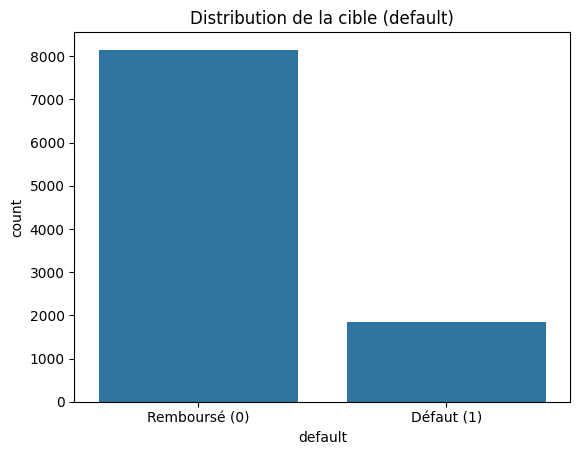

In [28]:
taux_defaut = df['default'].mean() * 100
print(f"Taux de défaut : {taux_defaut:.2f}%")

sns.countplot(x='default', data=df)
plt.title("Distribution de la cible (default)")
plt.xticks([0,1], ['Remboursé (0)', 'Défaut (1)'])
plt.show()


### Variables explicatives clés

- **FICO score** plus bas chez les clients en défaut → fort pouvoir discriminant.
- Variables financières (dette/encours/revenu) pertinentes → **on les conserve toutes**.


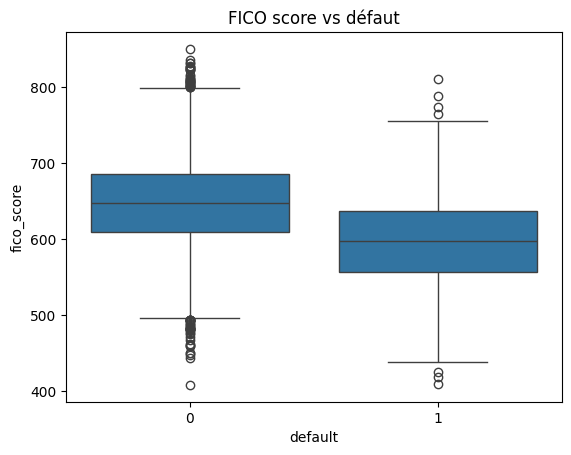

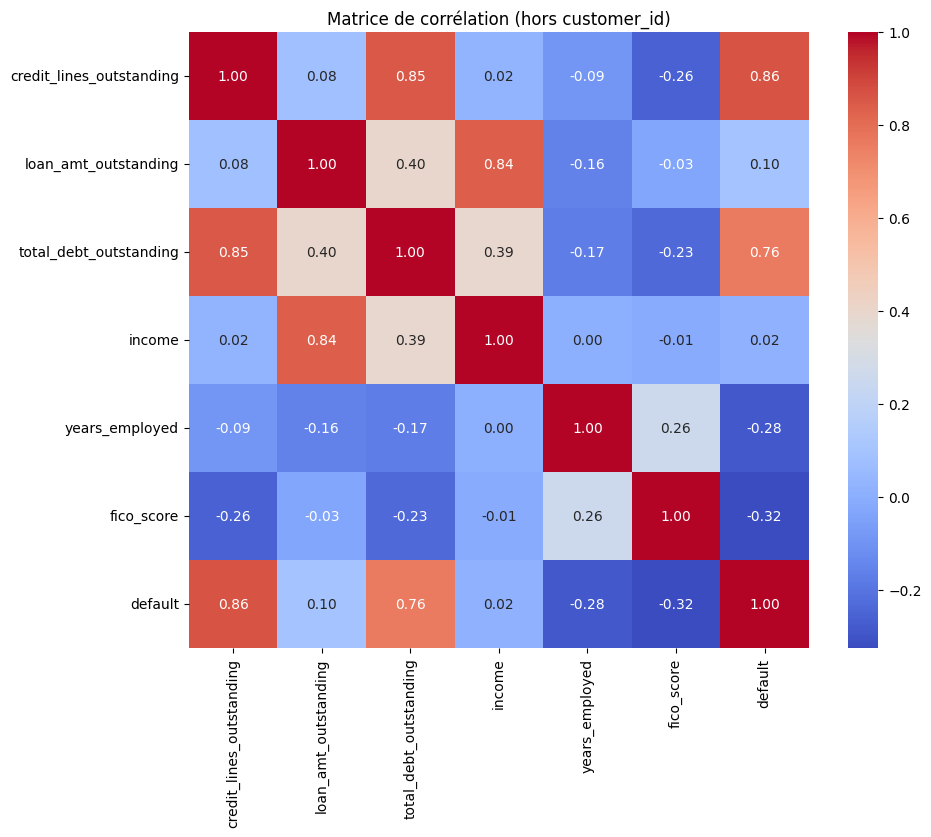

In [29]:
sns.boxplot(x='default', y='fico_score', data=df)
plt.title('FICO score vs défaut')
plt.show()

corr = df.drop(columns=['customer_id']).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation (hors customer_id)')
plt.show()


## 2) Feature engineering & séparation X/y (dans un module réutilisable)

On crée une feature robuste et standard en scoring crédit :  

**Formule :**  
`debt_income_variable = total_debt_outstanding / (income + ε)`

Cette variable représente le niveau d’endettement relatif au revenu.  
> **Remarque :** on ne supprime **aucune variable financière**, contrairement à certains exemples.


In [15]:
df= pd.read_csv('Loan_Data.csv')

In [16]:
df.columns

Index(['customer_id', 'credit_lines_outstanding', 'loan_amt_outstanding',
       'total_debt_outstanding', 'income', 'years_employed', 'fico_score',
       'default'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [9]:
df.describe()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


Taux de Défaut Crucial : La moyenne de la variable default est de 0.1851. Cela signifie que le taux de défaut est de 18.51%. C'est un taux significatif qui confirme que nous devons utiliser des métriques robustes comme l'AUC-ROC ou le F1-Score

Variation d'Échelle : L'income (≈70000 en moyenne) et le fico_score (≈637) sont sur des échelles très différentes ce qui rend l'étape de mise à l'échelle (scaling) absolument nécessaire avant d'utiliser la Régression Logistique ou d'autres modèles sensibles aux échelles.

### 1. Compréhension et Analyse de la Variable Cible (y)

Le cœur de ce projet est de prévoir le défaut de paiement

In [6]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
def load_data(path: str):
    df = pd.read_csv(path)
    # là on vient séparer les valeurs cibles des valeurs fatures
    y = df["default"].astype(int)
    X = df.drop(columns=["default", "customer_id"], errors="ignore")
    return X, y

def make_splits(X, y, test_size=0.2, val_size=0.2, random_state=42):
    # Train+Temp puis Temp -> Val/Test (stratifié)
    X_train, X_temp, y_train, y_temp = train_test_split(
X, y, test_size=test_size, stratify=y, random_state=random_state
)
    rel_val = val_size / (1 - test_size)
    X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=random_state
)
    return X_train, X_val, X_test, y_train, y_val, y_test


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


def numeric_pipeline(with_scaler: bool = True):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if with_scaler:
        steps.append(("scaler", StandardScaler()))
    return Pipeline(steps)

from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
    }

In [21]:
import argparse
import os
import joblib
import mlflow
import mlflow.sklearn
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay


In [ ]:
def build_model(kind: str):
    if kind == "logistic":
        clf = LogisticRegression(max_iter=200, n_jobs=None)
        pre = numeric_pipeline(with_scaler=True)
    elif kind == "tree":
        clf = DecisionTreeClassifier(max_depth=6, random_state=42)
        pre = numeric_pipeline(with_scaler=False)
    elif kind == "rf":
        clf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
        pre = numeric_pipeline(with_scaler=False)
    else:
        raise ValueError("doit être dans {logistic, tree, rf}")
    pipe = Pipeline([
        ("prep", pre),
        ("clf", clf),
    ])
    return pipe